In [1]:
# import needed packages
from cellpose import models
from tifffile import imread
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import napari
from skimage.filters import median
from skimage import exposure
from skimage import morphology
from skimage.measure import regionprops_table
import pandas as pd

c:\Users\zuzka\anaconda3\envs\cellpose\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'seaborn'

In [2]:
# The following code is used to process a 3D image into a 2D image
# that contains the sum of the projections along the x-axis. 
# The image is then processed with median filter and normalized to 0-1 to be used as input for cellpose.

im = imread('sinice_test/2022-01-05_CryoFM_NIBB-NO3_Lugoltest.lif - 4ch_NIBB+NO3_3.tif')
print(im.shape)

im_proj = np.max(im, axis=0)[:-1]

im_sum = np.sum(im_proj, axis=0)

# process the image with median filter
im_median = median(im_sum, selem=np.ones((3, 3)))
# normalize the image to 0-1
im_norm = exposure.rescale_intensity(im_median, out_range=(0, 1))

(8, 5, 575, 2048)
(8, 4, 575, 2048)


In [3]:
# load model
model = models.Cellpose(gpu=False, model_type='cyto')

# segment on all channels
masks, flows, styles, diams = model.eval(im_median, diameter=70, channels=[0,0])

In [4]:
# set up napari viewer
viewer = napari.Viewer()

In [5]:
diazocytes = imread('sinice_test/thresholded_0.4_C2divC4-2022-01-05_CryoFM_NIBB-NO3_Lugoltest.lif - 4ch_NIBB+NO3_3.tif.tif.tif')

viewer.add_image(diazocytes, name='diazocytes')
viewer.add_labels(masks, name='masks')
viewer.add_image(im_proj, name='im_proj')

<Image layer 'im_proj' at 0x110fe0790>

In [6]:
def get_diazocyte_mask(masks, diazocytes):
    # morphologically erode diazocytes
    diazocytes = morphology.binary_erosion(diazocytes, selem=np.ones((7,7)))
    # convert to int
    diazocytes = diazocytes.astype(int)

    # take only labels where there is a diazocyte
    diazocytes_ids = masks * diazocytes
    diazocytes_ids = np.unique(diazocytes_ids)[1:]
    diazocytes_masks = masks.copy()

    for i in range(masks.shape[0]):
        for j in range(masks.shape[1]):
            if diazocytes_masks[i,j] not in diazocytes_ids:
                diazocytes_masks[i,j] = 0

    return diazocytes_masks


masks = viewer.layers['masks'].data
diazocytes = viewer.layers['diazocytes'].data

diazocytes_masks = get_diazocyte_mask(masks, diazocytes)

viewer.add_labels(diazocytes_masks, name='masks')

<Labels layer 'masks [1]' at 0x1d280bd60>

In [16]:
# get the statistics for each diazocyte
im = imread('sinice_test/2022-01-05_CryoFM_NIBB-NO3_Lugoltest.lif - 4ch_NIBB+NO3_3.tif')
im_proj = np.sum(im, axis=0)
ch2 = im_proj[1]
ch4 = im_proj[3]
# stack channels
im_proj = np.stack((ch2, ch4))
im_proj = im_proj.transpose(1,2,0)


diazocytes_props = regionprops_table(diazocytes_masks, intensity_image=im_proj, properties=('label', 'area', 'mean_intensity', 'eccentricity', 'solidity', 'perimeter', 'centroid'))
# convert to dataframe
diazocytes_props = pd.DataFrame(diazocytes_props)
# get ch2/ch4 ratio
diazocytes_props['ch2/ch4'] = diazocytes_props['mean_intensity-0'] / diazocytes_props['mean_intensity-1']
diazocytes_props

,label,area,mean_intensity-0,mean_intensity-1,eccentricity,solidity,perimeter,centroid-0,centroid-1,ch2/ch4
0,53,3991,76.350539,143.219494,0.616806,0.919585,265.231493,286.574292,1399.699073,0.533102
1,65,4086,74.185267,184.556290,0.837641,0.930752,271.568542,342.779736,1297.242780,0.401966
2,67,4929,83.198823,219.571718,0.499730,0.900274,298.438600,350.950091,1354.137147,0.378914
3,70,3031,77.449357,189.247113,0.857695,0.929469,234.710678,345.574728,1173.169251,0.409250
4,71,11892,48.663808,117.314413,0.751422,0.930735,469.586832,353.816852,1494.065338,0.414815
5,73,2506,77.806065,202.235036,0.861346,0.948524,212.669048,349.269354,1255.781724,0.384731
6,78,3038,79.758723,210.585253,0.839571,0.967516,230.769553,352.502962,1406.575379,0.378748
7,86,2194,70.649499,189.871468,0.460379,0.916841,193.426407,360.571559,1214.706472,0.372091


In [18]:
# get all the masks that are not diazocytes
non_diazocytes_masks = masks.copy()
non_diazocytes_masks = non_diazocytes_masks - diazocytes_masks
viewer.add_labels(non_diazocytes_masks, name='non_diazocytes_masks')

<Labels layer 'non_diazocytes_masks' at 0x1e3e803a0>

In [19]:
non_diazocytes_props = regionprops_table(non_diazocytes_masks, intensity_image=im_proj, properties=('label', 'area', 'mean_intensity', 'eccentricity', 'solidity', 'perimeter', 'centroid'))
# convert to dataframe
non_diazocytes_props = pd.DataFrame(non_diazocytes_props)
# get ch2/ch4 ratio
non_diazocytes_props['ch2/ch4'] = non_diazocytes_props['mean_intensity-0'] / non_diazocytes_props['mean_intensity-1']
non_diazocytes_props

,label,area,mean_intensity-0,mean_intensity-1,eccentricity,solidity,perimeter,centroid-0,centroid-1,ch2/ch4
0,1,1695,36.569912,55.546313,0.854414,0.973020,178.509668,14.168142,1938.959292,0.658368
1,2,3946,44.496452,69.163203,0.672201,0.904009,273.504617,54.803092,1977.653573,0.643354
2,3,2948,50.929444,80.790706,0.708058,0.973902,211.480231,105.230665,2010.532225,0.630387
3,4,1664,57.143630,92.154447,0.561767,0.940113,172.752309,147.200721,2014.350962,0.620085
4,5,1561,59.046124,94.821268,0.892668,0.975625,177.160426,182.156951,2035.172966,0.622710
...,...,...,...,...,...,...,...,...,...,...
79,88,2664,63.346096,102.890015,0.917248,0.946023,229.254834,380.709084,1800.610736,0.615668
80,89,2416,83.395281,137.046358,0.918577,0.910324,224.911688,381.288907,1718.346854,0.608519
81,90,3276,85.736569,144.759768,0.817213,0.954545,247.681241,388.644689,1761.079060,0.592268
82,91,3659,64.814977,105.078163,0.772951,0.949896,255.633514,380.859798,1840.551244,0.616826


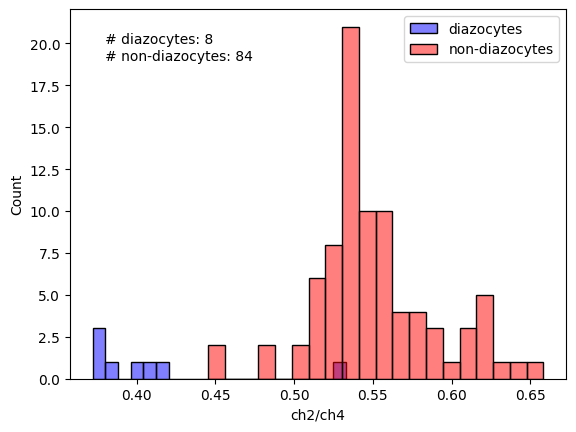

In [30]:
# plot the ch2/ch4 ratio for diazocytes and non-diazocytes masks
sns.histplot(data=diazocytes_props, x='ch2/ch4', color='blue', label='diazocytes', alpha=0.5, bins=20)
sns.histplot(data=non_diazocytes_props, x='ch2/ch4', color='red', label='non-diazocytes', alpha=0.5, bins=20)
# add count of diazocytes and non-diazocytes
plt.text(0.38, 20, f'# diazocytes: {len(diazocytes_props)}')
plt.text(0.38, 19, f'# non-diazocytes: {len(non_diazocytes_props)}')
plt.legend()
plt.show()